# Setup
If you have not run the below code in a separate Julia session, this notebook will not work.
```
using Pkg
Pkg.add("DrWatson")          
Pkg.activate("path/to/temp-tune")
Pkg.instantiate()

cd("path/to/temp-tune")
include(scriptsdir("setup_python.jl"))
```

## activate project

In [1]:
using Pkg
using DrWatson
@quickactivate "temp-tune"
println("current active project = ",Base.active_project())

current active project = /Users/pfields/Git/temp-tune/Project.toml


## setup plotting

In [2]:
include(srcdir("matplotlib_helpers.jl"))
setup_notebook_for_paper()
using_Py(true)

setup_rc_reset()
set_plot_style_for_paper(; venue="revtex")

Plot style set → venue=revtex, font='Arial'
Sizes (pt): label=10.0  tick=8.0  legend=8.0  mathtext.fontset=cm
Python     : /Users/pfields/Git/temp-tune/.conda/bin/python
Matplotlib : 3.10.8 | backend=Agg
 set plot style finished. exiting...



## other packages

In [3]:
using StatsBase, Statistics, LinearAlgebra, Printf, Random
using SpecialFunctions
using Parameters, Flux
using Optim, BenchmarkTools, JLD2, DataFrames, Graphs
using OptimizationOptimJL, Optimization
using Roots, Expectations
using Distributions
using Conda

In [4]:
include(srcdir("two_level_toy_model.jl"))

get_dkl (generic function with 1 method)

In [5]:
function get_c( c_map_, all_t, t)
    norm_t = ( t - minimum(all_t) ) / ( maximum(all_t) - minimum(all_t) )
    return c_map_(Float64(norm_t))
end

get_c (generic function with 1 method)

# Run several experiments to find optimal tau and plot means

### run simulations and plot

In [6]:
#= for different values of training samples, M, 
and ground truth energy gaps, Delta, fit many models, 
find the corresponding optimal taus, and do so for many different
number of ground states, holding the total number of states fixed
=#

Deltas = collect(2.5:0.25:9.5)

Ms= [unique(Int.(round.(10 .^(collect(.3:0.01:2.6)))));
    unique(Int.(round.(10 .^(collect(2.7:0.09:4.5)))))]

nlevels = 2
N_states=50
fraction_nground = collect(0.2:0.05:0.3)

dirstring = "simple_model_sweeps_new"

mkpath(datadir(dirstring))

nreps=10

10

In [7]:
df_mean_fits_all_Ns_ng=run_sweep_constant_N_states_vary_nground(N_states,
                                                    fraction_nground,
                                                    Ms, Deltas, dirstring,
                                                    nlevels, nreps );

running sims for frac ground states = 0.200000
/Users/pfields/Git/temp-tune/data/simple_model_sweeps_new/Nstates=50_nground=10.jld2 has already been run. skipping.
running sims for frac ground states = 0.250000
/Users/pfields/Git/temp-tune/data/simple_model_sweeps_new/Nstates=50_nground=12.jld2 has already been run. skipping.
running sims for frac ground states = 0.300000
/Users/pfields/Git/temp-tune/data/simple_model_sweeps_new/Nstates=50_nground=15.jld2 has already been run. skipping.


size(all_mean_delta_hat') = (23, 160)
size(Ms) = (160,)
size(Deltas) = (23,)

plots for nground = 10 and nexcited = 40


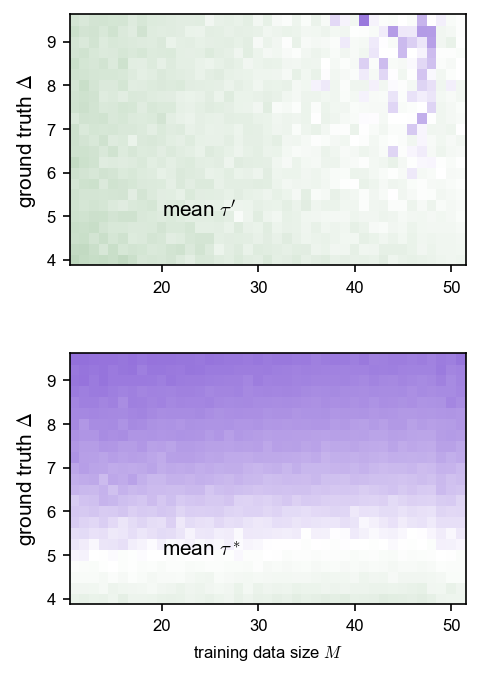

In [8]:
fig, ax = subplots(2,1,dpi=150, figsize=set_size_for_paper(1,1.5))

nground=10
nexcited=40 #determines which sim to import

fig, im1, im2 = plot_contour_fig_2(df_mean_fits_all_Ns_ng,
                                    N_states, nground, nexcited, Deltas, Ms,ax;
                    ticklabelsize=8, ylabelsize=8, xlabelsize=8 );
ax[1].text(20,5, "mean "*L"\tau'")
ax[2].text(20,5, "mean "*L"\tau^*")

println("\nplots for nground = $nground and nexcited = $nexcited")

# Figure 2 from paper

In [9]:
# ensure sims are imported from DrWatson.datadir()

Deltas = collect(2.5:0.25:9.5)

Ms= [unique(Int.(round.(10 .^(collect(.3:0.01:2.6)))));
    unique(Int.(round.(10 .^(collect(2.7:0.09:4.5)))))]

# nexcited=85
# nground=15
nlevels = 2
N_states=100
fraction_nground = collect(0.2:0.02:0.40)

dirstring = "simple_model_sweeps"

# mkpath(datadir(dirstring))

nreps=50

df_mean_fits_all_Ns_ng = DataFrame( N_states=[], nground=[], Ms=[], Deltas=[], nreps=[], #5
                                    all_mean_n_g_hat=[], all_mean_delta_hat=[], all_mean_LL=[], 
                                    tau_stars=[], tau_primes=[], 
                                    all_std_n_g_hat=[] , all_std_delta_hat=[] , all_std_LL=[] ,
                                    all_tau_star_std=[], all_tau_prime_st=[],
                                    phase_line=[] ) 
for frac_ng in fraction_nground
    # @printf "%f\n" frac_ng
    
    nground = Int(round(frac_ng*N_states))
    
    nexcited = N_states - nground
    
    temp_dict=load( datadir(dirstring*"/Nstates=$(N_states)_nground=$nground.jld2"))
    
    push!( df_mean_fits_all_Ns_ng, temp_dict["sweep_data"])

end

### for panels b-f

#### panels b-c

In [10]:

Δtrue=5
nlevels=2
nexcited=7
nground=3
nsampss = 5
N_states=nground+nexcited

ees, lbls = etrues(Δtrue,nlevels,nexcited,nground)
true_probs=get_probs_2( ees )

sampless=get_samples(true_probs, nsampss, N_states );
# freqs = get_freqs(sampless, lbls);
freqs = vcat([ 0.6, 0.4, 0.0], zeros(7) ); # data set used in paper


In [11]:
# fit model

minlosses, Δ_fff, Ls, pfit, Δs, Lp, minl_orig =fit_n_ground_and_Δ_hard_constraint( 
                                            freqs, nsampss , make_pfit=true, λ=0);

In [12]:
m_to_l=1:10 

1:10

In [13]:
# track how correct fit L is

L_true = [ zeros(nground) ; ones(nexcited) ]
Ls
ground_found_idx = (L_true .== 0) .&  (Ls .== 0)
ground_missed_idx = (L_true .== 0) .&  .! (Ls .== 0)
excited_found_idx = (L_true .== 1) .&  (Ls .== 1)
excited_missed_idx = (L_true .== 1) .& .! (Ls .== 1);
idxss = [excited_found_idx, ground_missed_idx, ground_found_idx, excited_missed_idx]

dkl_keys = ["e_f","g_m","g_f","e_m"]

sub_dkls = Dict( "forward"=>[], "reversed"=>[], "data"=>[] )

for (k, id) in zip( dkl_keys, idxss )
    append!(sub_dkls["forward"], get_dkl( true_probs[id] , pfit[id] ) )
    append!(sub_dkls["reversed"], get_dkl( pfit[id], true_probs[id]  ) )
    append!(sub_dkls["data"], get_dkl(  freqs[id], pfit[id]  ) )
end

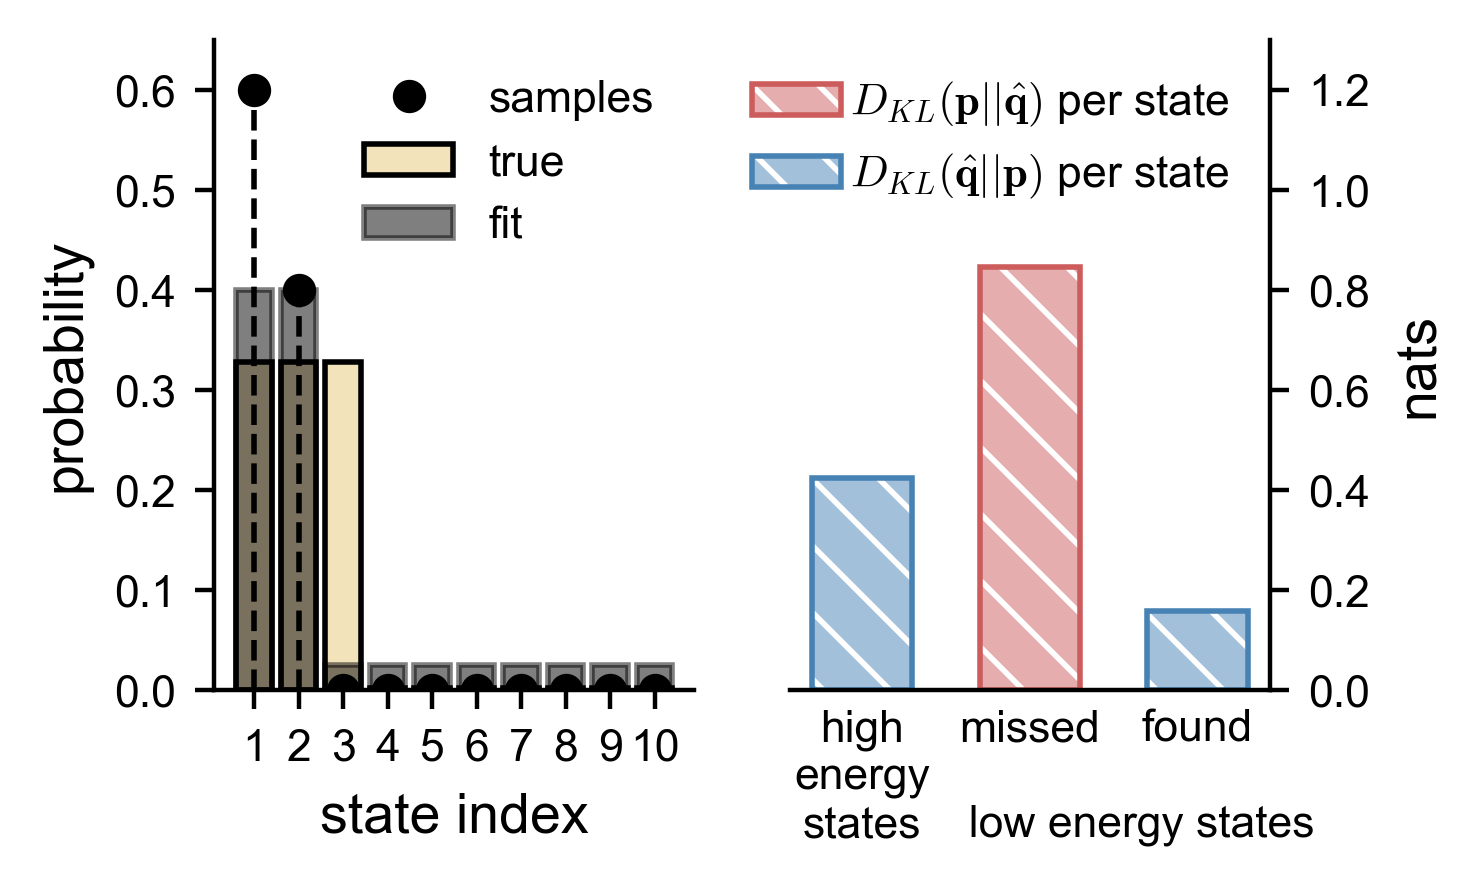

(0.0, 1.3)

In [14]:
fig, ax = subplots( 1,2, figsize=set_size_for_paper(1), dpi=400 )


plot_toy_probs_dkls(ax, sub_dkls, N_states, true_probs, pfit, freqs)

#### panels d-f

In [15]:
# sweep tau and track Dkls

tau_fits = collect(0.3:0.001:1.75)
p_fit_mod = similar( true_probs )

dkl_keys = ["g_f","g_m","e_f","total","e_m"]

idxss = [ground_found_idx, ground_missed_idx, excited_found_idx, fill(true, length(Ls)), excited_missed_idx ]
sub_dkls_tau = Dict( "forward"=>Dict(zip(dkl_keys, [] for i in 1:5)), 
                    "reversed"=>Dict(zip(dkl_keys, [] for i in 1:5)),
                    "data" =>Dict(zip(dkl_keys, [] for i in 1:5)) ,
                    "itself" =>Dict(zip(dkl_keys, [] for i in 1:5))
                            )

for (k,tt) in enumerate(tau_fits )
    p_fit_mod .= get_p_toy( Ls, Δ_fff/tt);
    true_probs_mod=get_probs_2( ees./tt )
    for (j,key) in enumerate( dkl_keys ) 
        append!( sub_dkls_tau["forward"][key],  get_dkl(true_probs[idxss[j]], p_fit_mod[idxss[j]]) )
        append!( sub_dkls_tau["reversed"][key], get_dkl(p_fit_mod[idxss[j]], true_probs[idxss[j]]) )
        append!( sub_dkls_tau["data"][key], get_dkl( freqs[idxss[j]], p_fit_mod[idxss[j]]) )
        append!( sub_dkls_tau["itself"][key], get_dkl( true_probs_mod[idxss[j]], true_probs[idxss[j]] ) )
        
    end
end

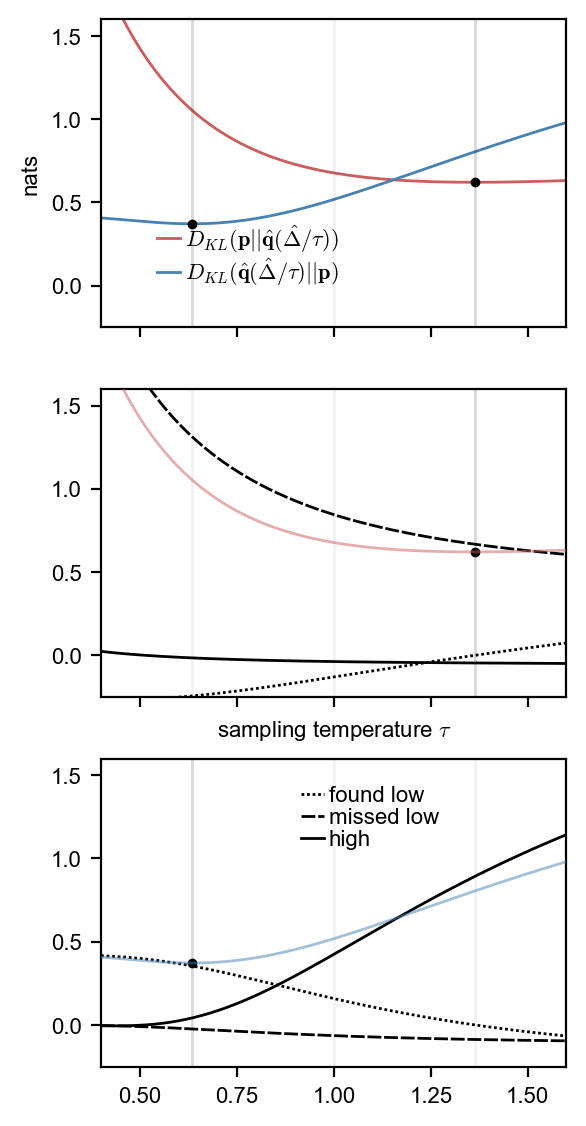

(0.4, 1.6)

In [16]:
fig, ax = subplots(3,1,sharex=true, sharey=true, figsize=(3,6.8), dpi=200)

toy_tau_plots(ax, tau_fits, sub_dkls_tau)

ax[1].set_ylim(-0.25,1.6)
ax[1].set_xlim(0.4,1.6)

### put altogether

In [17]:
set_plot_style_for_paper(;venue="revtex")

Plot style set → venue=revtex, font='Arial'
Sizes (pt): label=10.0  tick=8.0  legend=8.0  mathtext.fontset=cm
Python     : /Users/pfields/Git/temp-tune/.conda/bin/python
Matplotlib : 3.10.8 | backend=Agg
 set plot style finished. exiting...



size(all_mean_delta_hat') = (23, 160)
size(Ms) = (160,)
size(Deltas) = (23,)


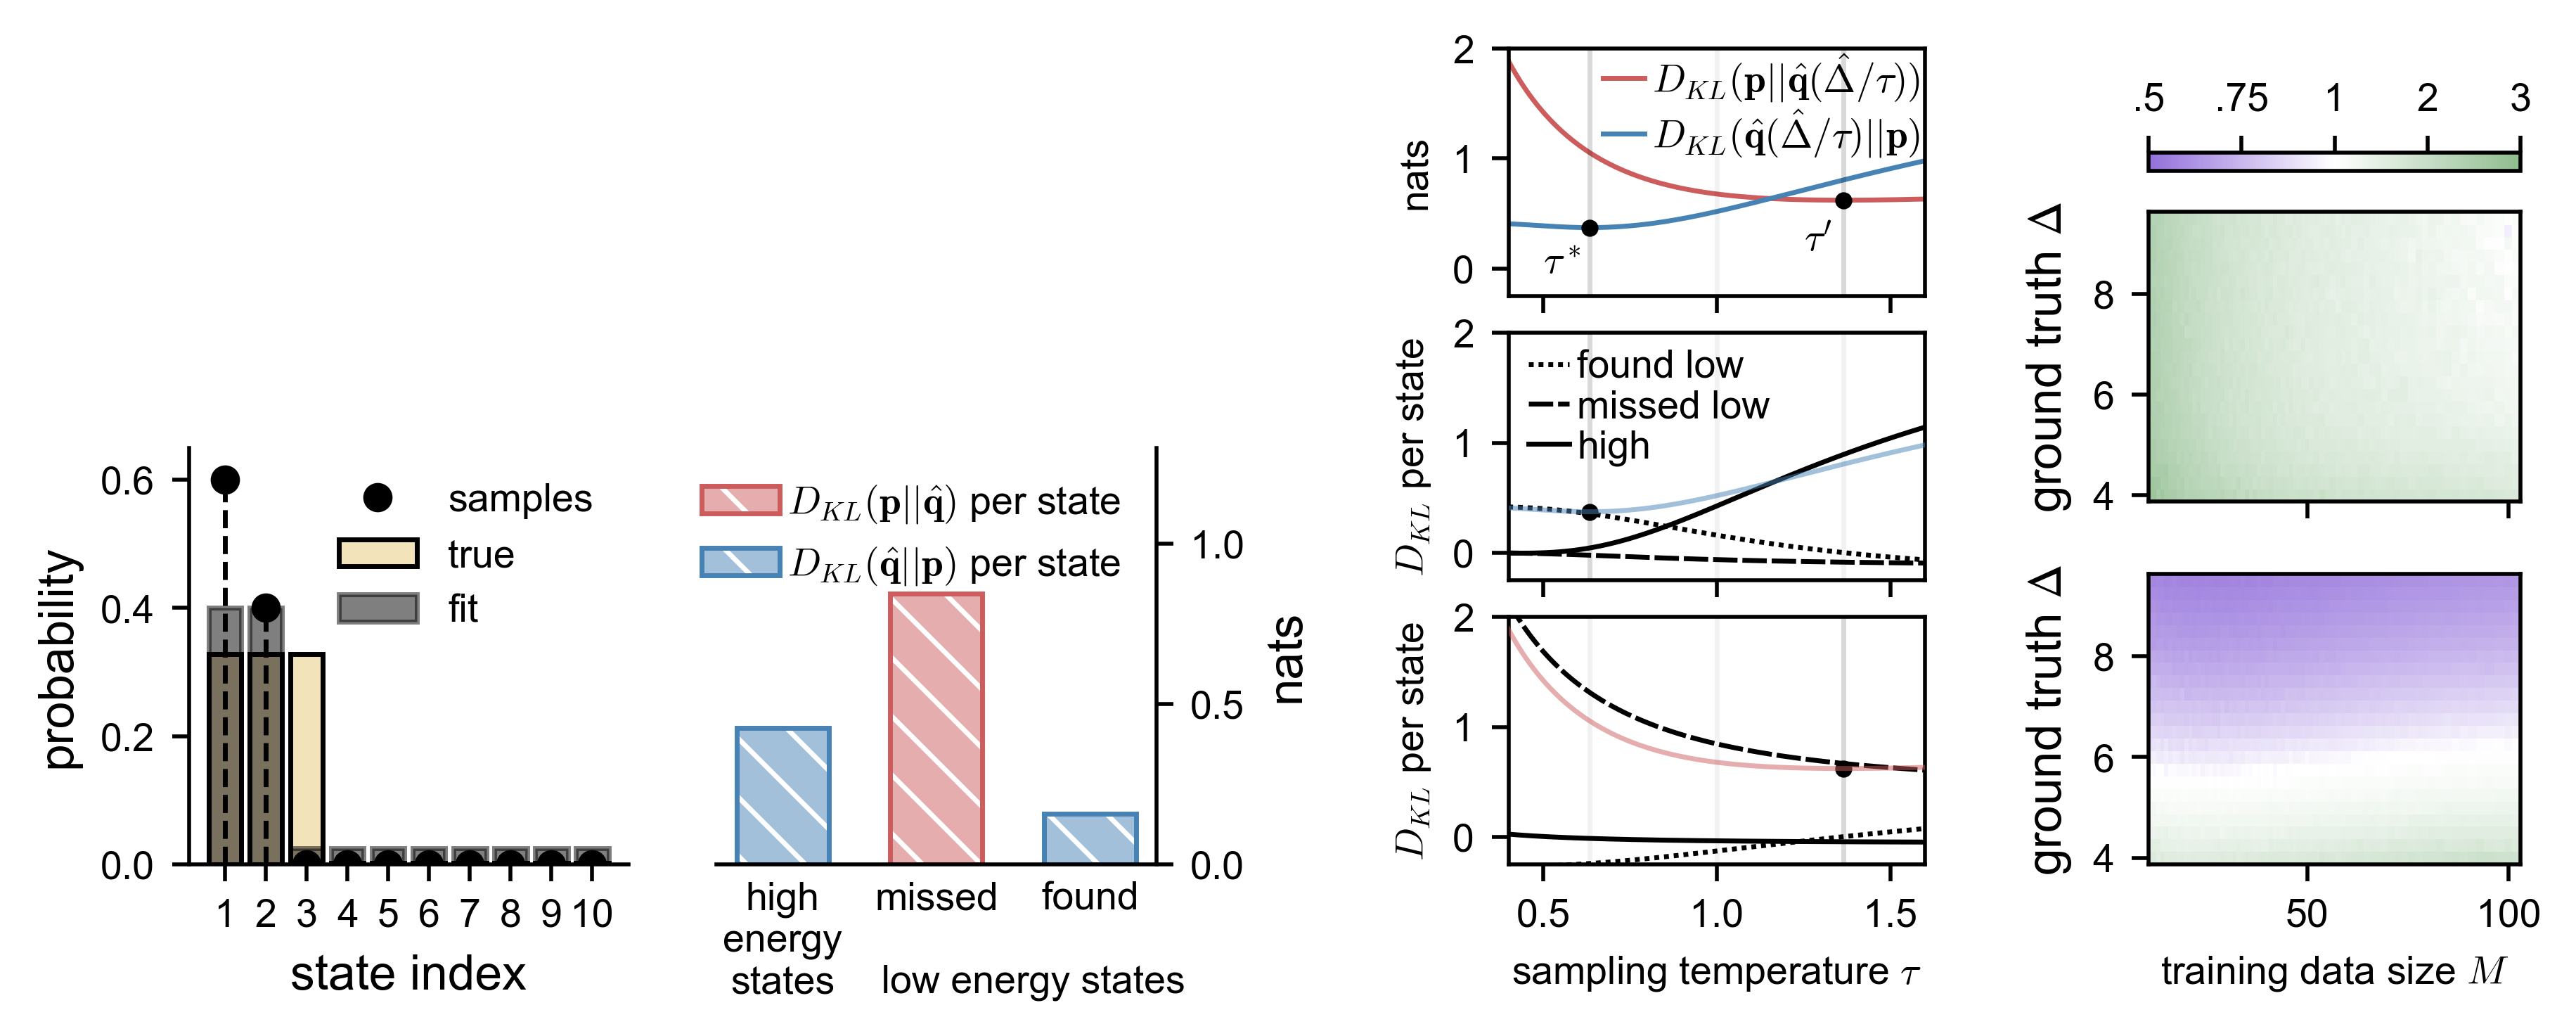

PyObject Text(2038.3774387712747, 0.5, '$D_{KL}$ per state')

In [18]:
gridspec=matplotlib.gridspec

fig = plt.figure(figsize=set_size_for_paper(2, 4.6/14 ), dpi=500)

# Explicit positions as fractions of the figure: left < middle < right
#               left   right  bottom  top
gs_left  = fig.add_gridspec(2, 2, left=0.06, right=0.45, bottom=0., top=1.2)
# gs_left =  fig.add_gridspec(1, 1, left=0.05, right=0.15, bottom=0., top=1.2)
# gs_mid   = fig.add_gridspec(3, 1, left=0.52, right=0.67, bottom=0., top=1, hspace=.15)

gs_mid   = fig.add_gridspec(3, 2, left=0.34, right=0.76, bottom=0., top=1., 
    hspace=.15, wspace=0.5)

gs_right = fig.add_gridspec(2, 1, left=0.85, right=1., bottom=0., top=1., hspace=0.25)

# gs_right = fig.add_gridspec(2, 1, left=0.73, right=.97, bottom=0., top=1, hspace=0.25)

# Left block: 2×2 equal-sized axes
ax_a11 = fig.add_subplot(gs_left[0, 0]); 
ax_a12 = fig.add_subplot(gs_left[0, 1]); 
# ax_a21 = fig.add_subplot(gs_left[1, 0]); ax_a21.set_title("LEFT 2×2 (2,1)")
# ax_a22 = fig.add_subplot(gs_left[1, 1]); ax_a22.set_title("LEFT 2×2 (2,2)")

# Middle block: 3 equal rows
ax_b1 = fig.add_subplot(gs_mid[0, 0])
ax_b2 = fig.add_subplot(gs_mid[1, 0])
ax_b3 = fig.add_subplot(gs_mid[2, 0])

# Right block: 2 equal rows
ax_c1 = fig.add_subplot(gs_right[0, 0]); 
ax_c2 = fig.add_subplot(gs_right[1, 0]); 

# plt.show()


ax_b1.sharey(ax_b2)
ax_b3.sharey(ax_b2)
ax_b1.sharex(ax_b2)
ax_b3.sharex(ax_b2)
# ax_b1.get_shared_x_axes().join(ax_b1, ax_b2, ax_b3)
# ax_b1.get_shared_y_axes().join(ax_b1, ax_b2, ax_b3)

mid_col_ax=[ax_b2,ax_b1,ax_b3]

ax_b1.set_ylim(-0.05,2)

toy_tau_plots(mid_col_ax, tau_fits, sub_dkls_tau ;  ticklabelsize=8, 
    ax1_leg_loc=(0.19,0.49), ax2_leg_loc=(0.01,0.4), 
    ylabelsize=8, ax2legsize=8, ax1legsize=8, xlabelsize=8)

for a in mid_col_ax[1:2:3]
    a.tick_params(labelbottom=false)
end
ax_c2.tick_params(labelbottom=false)

ax_b1.set_ylim(-0.25,2)

# fig, im1, im2 = plot_contour_fig_2(df_mean_fits_all_Ns_ng,
#                                     N_states, nground, nexcited, Deltas, Ms,ax;
#                     ticklabelsize=8, ylabelsize=8, xlabelsize=8 );
fig, im1, im2= plot_contour_fig_2(df_mean_fits_all_Ns_ng,
                                    100, 20, 80, Deltas, Ms, [ax_c2,ax_c1];
                    ticklabelsize=8, ylabelsize=8, xlabelsize=8,cbarlabelsize=8 );

ax_left=[ax_a12, ax_a11]
plot_toy_probs_dkls(ax_left, sub_dkls, N_states, true_probs, pfit, freqs)

ax_b2.text( 1.25, 0.16, L"\tau'" , size=8)
ax_b2.text( 0.5, -0.05, L"\tau^*" , size=8)


ax_right = [ax_c1,ax_c2]
cb=colorbar(im1, ax=ax_right,orientation="horizontal", 
    ticks=[0.5,.75,1, 2, 3],
    location="top")
cb.ax.set_xticklabels([".5", ".75", "1", "2", "3"])


ax_b1.set_ylabel(L"D_{KL}"*" per state", fontsize=8)
ax_b3.set_ylabel(L"D_{KL}"*" per state", fontsize=8)

# savefig(plotsdir("fig2_repoduced_.pdf"))